# PPO Homework

## PPO
[Proximal Policy Optimization (PPO)](https://arxiv.org/abs/1707.06347) is one of the most popular and widely used RL algorithms. It has been shown to produce excellent results, including a famous paper where OpenAI trained a PPO-based policy to [play Dota 2 at a superhuman level](https://arxiv.org/abs/1912.06680). It (or some variations) has also been used in many other applications, including robotics, optimization problems, trading, and natural language processing.

Your task in this notebook is to implement PPO and a couple of extensions that help its performance. PPO is one of the algorithms that greatly benefit from data-rich environments, since it is on-policy. Even a couple of years ago training PPO on more complex, robotic environments would have been a challenge because of the amount of compute required. Recently however, many physical engines have been optimized to run on GPUs, which allows us to parallelize the environment logic and thus run thousands of instances of the environment at the same time with minimal overhead. This allows us to collect a lot of data in a short amount of time, which is ideal for PPO.

We highly recommend you look through the original [PPO paper](https://arxiv.org/abs/1707.06347) to see the derivation and motivation for the algorithm. The key takeaway is that PPO tries to limit how much we change the policy in one update step, to enforce a smooth training process. This can be done in multiple ways; in PPO we simply clip the objective function to never get an update that is too big. There are other, much more sophisticated ways to do this (for example [TRPO](https://arxiv.org/pdf/1502.05477)), however in practice PPO works very well, is much easier to implement, and has faster runtime.

Even though PPO is a well-known algorithm, it is not that easy to track down all the implementation details. This homework is partially based on a number of implementations, including the one from [Brax](https://github.com/google/brax/tree/main/brax/training/agents/ppo), [stable_baselines3](https://github.com/DLR-RM/stable-baselines3/tree/master/stable_baselines3/ppo), [cleanrl](https://github.com/vwxyzjn/cleanrl/blob/master/cleanrl/ppo_continuous_action.py) and an excellent [blog post](https://iclr-blog-track.github.io/2022/03/25/ppo-implementation-details/), that compares different existing implementations and describes differences between them. In RL it is often the case that small, seemingly insignificant implementation details can make or break an algorithm, so some care is needed when writing the code :)

## JAX
We will take advantage of JAX and its ecosystem to implement a parallel, GPU-accelerated version of PPO and train it on the environments from [Brax suite](https://github.com/google/brax). Due to the fact that the training loop and data collection will be compiled and parallelized on the GPU, the training should take only a few minutes on a single, consumer-grade GPU.

JAX can be challenging to work with at first, especially when compared to PyTorch. It is important to take time and understand what is going on in the code and how JAX works. We recommend going through the official [JAX tutorial](https://docs.jax.dev/en/latest/notebooks/thinking_in_jax.html) to get started.

The goal of this homework is not only to introduce you to PPO, but also to give you an idea of what working with JAX looks like for a project slightly bigger than a standard lab notebook. AT the same time, most of the code that you will need to write are simple operations on arrays, similar to numpy. The hard part of JAX - that is the control flow - is already written for you.

## Grading

The homework will be graded on a scale of 0 to 10. This grade is worth 30% of the final grade from the laboratory part of the course. The grades for each part of the homework are listed in their respective sections.

**IMPORTANT**: Be sure to stick to the requirements of each section and follow the instructions given there. Do not modify the code outside of the `TODO` sections!

## LLM usage
We encourage you to use LLMs to help understand the code and PPO theory, especially since code in JAX can be challenging for beginners to work with. However, you should **NOT** use LLMs to write code, only to understand it.

## Utilities (1 pt.)

In [1]:
!pip -q install jax
!pip -q install brax
!pip -q install distrax
!pip -q install flax

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 356.9/356.9 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.3/313.3 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.0/101.0 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
import time
from dataclasses import dataclass
from typing import NamedTuple, Tuple

import distrax
import flax.linen as nn
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from brax import envs
from brax.envs.wrappers.training import AutoResetWrapper, EpisodeWrapper, VmapWrapper
from flax.linen.initializers import constant, orthogonal
from flax.training.train_state import TrainState

Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'


JAX supports working on data structures, like NamedTuples, through pytrees. This allows us to pass them around as parameters to jit-compiled functions, automatically add batch dimensions, and more. For now we will only define the data structures, as we would in normal Python.

In [3]:
# Here we will store a single transition collected from the environment.
class Transition(NamedTuple):
    obs: jnp.ndarray
    action: jnp.ndarray
    reward: jnp.ndarray
    done: jnp.ndarray
    value: jnp.ndarray
    log_prob: jnp.ndarray


# After each rollout, we collect information about it in this structure.
class RolloutInfo(NamedTuple):
    completed_return: jnp.ndarray
    completed_length: jnp.ndarray
    completed: jnp.ndarray


# We will also need a place to store the running mean and variance, for the purpose of normalization of observations and rewards.
class RunningNorm(NamedTuple):
    mean: jnp.ndarray
    var: jnp.ndarray
    count: jnp.ndarray


# This will be useful to organize the internal state of the training process
class RunnerState(NamedTuple):
    train_state: object
    env_state: object
    obs: jnp.ndarray
    rng: jnp.ndarray
    obs_norm: RunningNorm
    rew_norm: RunningNorm
    running_returns: jnp.ndarray
    episode_returns: jnp.ndarray
    episode_lengths: jnp.ndarray


def init_running_norm(shape):
    return RunningNorm(
        mean=jnp.zeros(shape, dtype=jnp.float32),
        var=jnp.ones(shape, dtype=jnp.float32),
        count=jnp.array(1e-4, dtype=jnp.float32),
    )


# This function takes the RunningNorm class and updates it with data coming from a fresh batch of data.
def update_running_norm(norm: RunningNorm, x: jnp.ndarray) -> RunningNorm:
    # TODO: implement the update_running_norm function. It should compute the mean and variance of the batch,
    # and update the running mean and variance so that they reflect the entire dataset (old + new).
    # HINT:You may look up batched version of Welford's algorithm to get a good implementation and numerical stability.

    # mean update
    old_mean = norm.mean
    old_count = norm.count
    x_count = x.shape[0]
    x_mean = jnp.mean(x, axis=0)
    total_count = x_count + old_count
    new_mean = old_mean + (x_mean - old_mean) * x_count / total_count

    # variance update
    old_var = norm.var
    x_var = jnp.var(x, axis=0)
    new_var = (old_var * old_count + x_var * x_count + ((x_mean - old_mean) ** 2) * old_count * x_count / total_count) / total_count
    # END TODO

    return RunningNorm(mean=new_mean, var=new_var, count=total_count)


# Normalize the input data using the current state of RunningNorm.
def normalize(
    x: jnp.ndarray,
    norm: RunningNorm,
    eps: float = 1e-6,
    clip: float | None = None,
) -> jnp.ndarray:
    # TODO: use the running norm to normalize the given input. After normalization clip it to range [-clip, clip] (if clip parameter is present)
    # To avoid division by zero, use eps when normalizing.

    # normalizing
    x_normalized = (x - norm.mean) / (jnp.sqrt(norm.var) + eps)

    # clipping
    if clip is not None:
      y = jnp.clip(x_normalized, min=-clip, max=clip)
    else:
      y = x_normalized
    # END TODO

    return y

In [4]:
# This is a convenience function to create the environment with the appropriate wrappers.
def make_env(config, num_envs: int | None = None):
    env = envs.get_environment(config.env_name, backend=config.backend)

    # This wrapper keeps track of the lengths of episodes and sends the truncation signal if needed.
    env = EpisodeWrapper(env, episode_length=config.episode_length, action_repeat=1)

    # This wrapper automagically parallelizes the environment logic. This can be done thanks to JAX's vmap.
    # The env that we get from it will be vectorized, meaning that observations, actions, rewards etc. will have an extra leading dimension corresponding to the number of parallel environments.
    env = VmapWrapper(env, batch_size=config.num_envs if num_envs is None else num_envs)

    # This wrapper automagically resets the environment when it receives a done (truncated or terminated) signal.
    # It resets only those of parallel environments that are done, not all of them.
    env = AutoResetWrapper(env)

    return env

## Configuration

In [5]:
# This is the configuration class for PPO. While it is not technically necessary, we recommend you know what these parameters do.
@dataclass
class PPOConfig:
    # We can use any of the Brax environments here, ant is the one we want to use in the end, for testing you can try other, simpler ones.
    env_name: str = "ant"
    # Brax offers multiple physical backends. Spring is the fastest, but also least accurate. It will be enough for this homework, since it works reasonably well with Ant or Humanoid models.
    backend: str = "spring"

    # Since we are working with parallel environments, we can easily push the number of total timesteps to tens of millions, which is necessary for more complex environments.
    total_timesteps: int = 10_000_000
    # The number of parallel environments should be as high as possible, but fit on your GPU, the default here should work on Colab.
    num_envs: int = 1024

    # This is the length of a rollout, i.e. how many transitions (per environment) we collect before we perform an update.
    rollout_length: int = 32
    update_epochs: int = 16
    num_minibatches: int = 16

    lr: float = 3e-4
    gamma: float = 0.99
    gae_lambda: float = 0.95
    clip_eps: float = 0.2
    vf_coef: float = 0.5
    ent_coef: float = 0.0
    max_grad_norm: float = 0.5

    episode_length: int = 1000
    hidden_sizes: Tuple[int, ...] = (256, 256)
    activation: callable = nn.tanh
    anneal_lr: bool = True

    normalize_advantage: bool = True
    normalize_obs: bool = True
    normalize_reward: bool = True

    norm_eps: float = 1e-6
    obs_clip: float = 10.0
    reward_clip: float = 10.0
    max_log_ratio: float = 20.0

    # For evaluation we will also use parallel environments, so that a single evaluation phase is very fast.
    eval_every_env_steps: int = 500_000
    eval_num_envs: int = 1024
    eval_horizon: int = 1000

    seed: int = 0

    def __post_init__(self):
        self.batch_size = self.num_envs * self.rollout_length
        self.minibatch_size = self.batch_size // self.num_minibatches
        self.num_updates = self.total_timesteps // self.batch_size

## Networks (3 pts.)

PPO is an actor-critic algorithm. The actor is a network that will output a Gaussian distribution over actions, and the critic is a network that will output a scalar, which is the estimated value function.

The implementation here is based on the [blog post](https://iclr-blog-track.github.io/2022/03/25/ppo-implementation-details/) (37 implementation details of PPO) mentioned above, but with some changes. In particular, your implementation should satisfy the following requirements:
* use orthogonal initialization for the actor and the critic weights and constant 0.0 initialization for bias
* use separate networks for the actor and the critic
* mean and log_std output of the actor should **both be dependent** on the observation
* The raw action sampled from the Gaussian distribution can fall outside of the action space range, so we need to apply a squashing function (tanh) to it. This in turn means that we need to recompute the log-probability of the action, just like we did in the [SAC notebook from lab 7](https://github.com/mim-ml-teaching/public-rl-2025-26/blob/main/labs/RL_Lab_7_Soft_Actor_Critic_student.ipynb)
* use `distrax.MultivariateNormalDiag` to construct the action distribution and sample from it. Distributions constructed with [distrax](https://github.com/google-deepmind/distrax/tree/main) allow calculating the log-probability of the action and the entropy of the distribution.

In [6]:
class CriticNet(nn.Module):
    hidden_sizes: Tuple[int, ...] = (256, 256)
    activation: callable = nn.tanh

    @nn.compact
    def __call__(self, obs: jnp.ndarray):
        hidden_init = orthogonal(np.sqrt(2))
        critic_head_init = orthogonal(1.0)

        # TODO implement value network
        # Remember about proper initialization described above
        x = obs

        for hidden_size in self.hidden_sizes:
          x = nn.Dense(features=hidden_size, kernel_init=hidden_init, bias_init=constant(0.0))(x)
          x = self.activation(x)

        value = nn.Dense(features=1, kernel_init=critic_head_init, bias_init=constant(0.0))(x)
        # END TODO

        return jnp.squeeze(value, axis=-1)


class ActorNet(nn.Module):
    hidden_sizes: Tuple[int, ...] = (256, 256)
    action_dim: int = 1
    activation: callable = nn.tanh

    @nn.compact
    def __call__(self, obs: jnp.ndarray):
        hidden_init = orthogonal(np.sqrt(2))
        actor_head_init = orthogonal(0.01)
        # TODO implement actor network
        # Remember about proper initialization described above
        x = obs

        for hidden_size in self.hidden_sizes:
          x = nn.Dense(features=hidden_size, kernel_init=hidden_init, bias_init=constant(0.0))(x)
          x = self.activation(x)

        mean = nn.Dense(features=self.action_dim, kernel_init=actor_head_init, bias_init=constant(0.0))(x)
        log_std = nn.Dense(features=self.action_dim, kernel_init=actor_head_init, bias_init=constant(0.0))(x)
        # END TODO

        return mean, log_std


class PPOAgent(nn.Module):
    hidden_sizes: Tuple[int, ...] = (256, 256)
    action_dim: int = 1
    activation: callable = nn.tanh

    # setup is a special flax method that is called to initialize the parameters of the networks.
    def setup(self):
        self.actor_net = ActorNet(
            hidden_sizes=self.hidden_sizes,
            action_dim=self.action_dim,
            activation=self.activation,
        )
        self.critic_net = CriticNet(
            hidden_sizes=self.hidden_sizes,
            activation=self.activation,
        )

    def critic(self, obs: jnp.ndarray):
        return self.critic_net(obs)

    def actor(self, obs: jnp.ndarray):
        return self.actor_net(obs)

    # Squashes the action and recomputes the log-probability of the new, bounded action.
    # This is a numerically stable version of this calculation, introduced in the SAC paper (https://arxiv.org/abs/1801.01290)
    def _apply_squashing_function(self, mean, action, logp_action):
        tanh_logp_action = logp_action - jnp.sum(
            2 * (jnp.log(2) - action - nn.softplus(-2 * action)), axis=-1
        )
        tanh_mean = jnp.tanh(mean)
        tanh_action = jnp.tanh(action)
        return tanh_action, tanh_mean, tanh_logp_action

    # Samples from a Gaussian, applies tanh for bounded actions in [-1, 1], with correct log-prob.
    # Deterministic action is tanh(mean) (mean of the base Gaussian), it will be used for evaluation.
    def act(self, params, obs: jnp.ndarray, rng: jax.Array):
        mean, log_std = self.apply(params, obs, method=self.actor)
        # TODO: implement the act function. It should construct the distribution, sample from it,
        # and use _apply_squashing_function to get the final action, deterministic action, and log-probability.

        # constructing distribution
        normal_distribution = distrax.MultivariateNormalDiag(loc=mean, scale_diag=jnp.exp(log_std))

        # sampling from distribution
        sample = normal_distribution.sample(seed=rng)
        log_prob_sample = normal_distribution.log_prob(sample)

        # using 'apply_squashing_function' function
        squashed_action, deterministic_squashed_action, logp_squashed_action = self._apply_squashing_function(mean, sample, log_prob_sample)
        # END TODO

        return squashed_action, deterministic_squashed_action, logp_squashed_action

    # Log-prob of stored squashed actions; entropy uses base Gaussian (common surrogate for tanh policies).
    def get_action_log_prob_and_entropy(
        self, params, obs: jnp.ndarray, squashed_action: jnp.ndarray
    ):
        mean, log_std = self.apply(params, obs, method=self.actor)
        # TODO: implement the get_action_log_prob_and_entropy function. It should construct the probability distribution,
        # compute the log-probability of the action, and then use _apply_squashing_function to recompute the log-probability of the squashed action.
        # Lastly it should also return the entropy of the base Gaussian distribution.
        # **IMPORTANT**: The action passed here has already been squashed, to properly compute the log-probability you will have to unsquash it first!
        # Be careful with numerical instabilities here!

        # constructing distribution
        normal_distribution = distrax.MultivariateNormalDiag(loc=mean, scale_diag=jnp.exp(log_std))

        # before inversing, we must clip 'squashed_action'
        squashed_action_clipped = jnp.clip(squashed_action, min=-1+1e-6, max=1-1e-6)

        # inversing the tanh operation
        action = jnp.arctanh(squashed_action_clipped)

        # obtaining 'squashed_log_probability'
        log_prob_action = normal_distribution.log_prob(action)
        _, _, squashed_log_prob = self._apply_squashing_function(mean, action, log_prob_action)

        # computing entropy
        entropy = normal_distribution.entropy()

        # END TODO
        return squashed_log_prob, entropy

    # This function is required by the nn.Module class to function, but we will not use it.
    def __call__(self, obs: jnp.ndarray):
        mean, log_std = self.actor(obs)
        value = self.critic(obs)
        return mean, log_std, value

## PPO core (3 pts.)
In this section we will implement the core of PPO algorithm, the loss function, and generalized advantage estimation.

### GAE (1 pt.)
Since PPO is an on-policy algorithm, once we train the policy on a freshly collected batch of data, we need to discard it and collect a new batch for the next update. This means that each update is based on a single batch of data, which is very inefficient. In algorithms like REINFORCE, we used Monte Carlo over entire trajectories to estimate the value function, but this combined with the on-policy nature of PPO makes it very slow.

To address this, PPO uses Generalized Advantage Estimation (GAE) to estimate the value function. You can think of GAE as a mix between Monte Carlo (taking entire trajectories) and TD (taking only one step). The GAE parameter (usually denoted as $\lambda$) controls (informally speaking) how much we look into the future. When $\lambda = 1$ we get Monte Carlo estimate, when $\lambda = 0$ we get TD estimate.

Instead of rolling out the entire trajectory, we will only roll out $T$ steps, and then use GAE to estimate the advantage function, for timestep $t \in [0, T]$ we have:

$$
A_t = \delta_t + (\gamma \lambda) \delta_{t+1} + (\gamma \lambda)^2 \delta_{t+2} + \ldots + (\gamma \lambda)^{T+1-t} \delta_{T-1}
$$
where,
$$
\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)
$$

(for more details see equations 11 and 12 in the [PPO paper](https://arxiv.org/abs/1707.06347))

In the code we have
* $\gamma$ -> `gamma`
* $\lambda$ -> `gae_lambda`
* $V(s_{t})$ -> `traj.value[t]` (this is why we store value function with each transition in the trajectory)

In [7]:
# This computes the advantages and value targets using GAE for the trajectory `traj`.
# `last_value` is the value function estimate at the last timestep (V(S_T) in the equation above).
# Notice that `traj` is not a single tuple of type Transition, but a batch of them (batch_size, T), thanks to JAX pytrees.
def compute_gae(traj: Transition, last_value, gamma, gae_lambda):
    def scan_gae(carry, t):
        gae, next_value = carry
        # TODO: calculate a single step of GAE. You have to first compute the delta for timestep t
        # Then use it to compute advantage.
        # Remember to zero out bootstrapped value if done is true!

        # accessing information from trajectory
        value, reward, done = traj.value[t], traj.reward[t], traj.done[t]

        # to address cases when trajectory is in the last step
        multiplier_done = 1 - done

        # calculating delta
        delta_t = reward + gamma * next_value * multiplier_done - value

        # calculating advantage
        advantage = delta_t + gamma * gae_lambda * gae * multiplier_done
        gae = advantage
        # END TODO

        # The value estimate for timestep t is passed to the next iteration to be the `next_value`
        return (gae, traj.value[t]), gae

    # We scan over the trajectory in reverse order, starting from the last timestep.
    T = traj.reward.shape[0]
    time_idx = jnp.arange(T - 1, -1, -1)
    # JAX scan is a function designed to iterate over arrays and accumulate results of intermediate calculations in a `carry` variable.
    (_, _), advantages_rev = jax.lax.scan(
        scan_gae,
        (jnp.zeros_like(last_value), last_value),
        time_idx,
    )
    advantages = jnp.flip(advantages_rev, axis=0)
    targets = advantages + traj.value
    return advantages, targets

### PPO Loss (2 pts.)
Here we will implement the PPO loss itself. Again, to better understand the loss we encourage you to take a look at the original [PPO paper](https://arxiv.org/abs/1707.06347), or a [blog from OpenAI](https://spinningup.openai.com/en/latest/algorithms/ppo.html). The policy loss is the main thing to compute:
$$
L(s, a, \theta, \theta_{old}) = -\min \left(\frac{\pi_\theta(a|s)}{\pi_{\theta_{old}}(a|s)} A(s, a), \text{clip}\left(\frac{\pi_\theta(a|s)}{\pi_{\theta_{old}}(a|s)}, 1-\epsilon, 1+\epsilon\right) A(s,a)\right)
$$
In our case we do not have access to $\theta_{old}$, but we do have access to old log_probs stored in the batch, which we can use instead.

We will also need a value loss, which is just the MSE between values computed for the current batch and targets (computed by the GAE method above).

Additionally, to encourage exploration and prevent collapsing of the action distribution we will add an entropy bonus to the loss. This bonus is simply a mean over entropy on the batch (computed by `get_action_log_prob_and_entropy`).

One of the tricks to make PPO work better and stabilize the training is to implement advantage normalization. This is also part of the task. In this context we simply want to normalize each minibatch of advantages separately.

In [8]:
def ppo_loss(
    params,
    agent,
    batch: Transition,
    advantages: jnp.ndarray,
    targets: jnp.ndarray,
    cfg: PPOConfig,
):
    log_prob, entropy = agent.get_action_log_prob_and_entropy(
        params, batch.obs, batch.action
    )
    value = agent.apply(params, batch.obs, method=agent.critic)

    # TODO: implement the PPO actor, critic and entropy losses.
    # First normalize the advantages if needed
    # Then compute the unclipped and clipped ratios and compute the actor loss
    # Finally compute the value and entropy losses

    # normalzing advantages
    if cfg.normalize_advantage:
        advantages = (advantages - jnp.mean(advantages)) / (jnp.std(advantages) + 1e-8)

    # calculating ratios
    old_log_prob = batch.log_prob
    ratio = jnp.exp(log_prob - old_log_prob) # using the properties of log
    ratio_clipped = jnp.clip(ratio, min=1-cfg.clip_eps, max=1+cfg.clip_eps) * advantages
    ratio_unclipped = ratio * advantages

    # computing losses
    actor_loss = jnp.mean(-jnp.minimum(ratio_clipped, ratio_unclipped))
    value_loss = jnp.mean((targets - value)**2)
    entropy_loss = jnp.mean(entropy)

    # END TODO

    total_loss = actor_loss + cfg.vf_coef * value_loss - cfg.ent_coef * entropy_loss
    return total_loss, (actor_loss, value_loss, entropy_loss)

## Update Step

Training components written in JAX follow a specific pattern. Usually we create a function that will have more functions defined inside it and will return a jit-compiled version of those functions. This is done to avoid recompiling the entire training loop on each iteration, and to make it more efficient.

In this case, we have a `make_update_fn` function which defines all the logic inside of it and returns a jit-compiled version of the `update_step` function. This can seem a bit confusing, but it is a common pattern in JAX, since it saves us from passing all the attributes as parameters.

In [9]:
class PPOTrainer:
    def __init__(self, config: PPOConfig, env, agent):
        self.config = config
        self.env = env
        self.agent = agent

    def init_runner(self, rng: jax.Array):
        rng, init_rng, reset_rng = jax.random.split(rng, 3)
        env_state = self.env.reset(reset_rng)
        obs = env_state.obs
        obs_dim = obs.shape[-1]

        params = self.agent.init(init_rng, jnp.zeros((1, obs_dim)))

        # We will use learning rate annealing, so we need a schedule function
        def learning_rate_schedule(step):
            frac = 1.0 - step / (
                self.config.num_updates
                * self.config.update_epochs
                * self.config.num_minibatches
            )
            return self.config.lr * frac

        tx = optax.chain(
            optax.clip_by_global_norm(self.config.max_grad_norm),
            optax.adam(
                learning_rate_schedule if self.config.anneal_lr else self.config.lr,
                eps=1e-5,
            ),
        )

        train_state = TrainState.create(apply_fn=self.agent.apply, params=params, tx=tx)

        obs_norm = init_running_norm((obs_dim,))
        rew_norm = init_running_norm(())
        running_returns = jnp.zeros((self.config.num_envs,), dtype=jnp.float32)
        episode_returns = jnp.zeros((self.config.num_envs,), dtype=jnp.float32)
        episode_lengths = jnp.zeros((self.config.num_envs,), dtype=jnp.int32)

        return RunnerState(
            train_state=train_state,
            env_state=env_state,
            obs=obs,
            rng=rng,
            obs_norm=obs_norm,
            rew_norm=rew_norm,
            running_returns=running_returns,
            episode_returns=episode_returns,
            episode_lengths=episode_lengths,
        )

    def make_update_fn(self):
        cfg = self.config
        env = self.env
        agent = self.agent

        # This function rolls out all the parallel environments for one step.
        def env_step(carry, _):
            runner_state = carry

            if cfg.normalize_obs:
                obs_norm = update_running_norm(runner_state.obs_norm, runner_state.obs)
                obs_in = normalize(
                    runner_state.obs, obs_norm, eps=cfg.norm_eps, clip=cfg.obs_clip
                )
            else:
                obs_norm = runner_state.obs_norm
                obs_in = runner_state.obs

            rng, act_rng = jax.random.split(runner_state.rng)
            action, _, log_prob = agent.act(
                runner_state.train_state.params, obs_in, act_rng
            )
            value = agent.apply(
                runner_state.train_state.params, obs_in, method=agent.critic
            )

            # Notice that we supply batch of actions to the environment, and it returns batch of next states.
            # This function is jit-compiled, and so the env.step is jit-compiled as well.
            # This is what allows for extreme speed of Jax-based training.
            next_env_state = env.step(runner_state.env_state, action)
            next_obs = next_env_state.obs
            reward = next_env_state.reward
            done = next_env_state.done.astype(jnp.float32)

            return_for_norm = runner_state.running_returns * cfg.gamma + reward
            if cfg.normalize_reward:
                rew_norm = update_running_norm(runner_state.rew_norm, reward)
                reward_out = reward / jnp.sqrt(jnp.maximum(rew_norm.var, cfg.norm_eps))
                reward_out = jnp.clip(reward_out, -cfg.reward_clip, cfg.reward_clip)
            else:
                rew_norm = runner_state.rew_norm
                reward_out = reward
            next_running_returns = return_for_norm * (1.0 - done)

            new_episode_returns = runner_state.episode_returns + reward
            new_episode_lengths = runner_state.episode_lengths + 1
            completed_return = jnp.where(done > 0.0, new_episode_returns, 0.0)
            completed_length = jnp.where(done > 0.0, new_episode_lengths, 0)

            episode_returns = new_episode_returns * (1.0 - done)
            episode_lengths = (new_episode_lengths * (1.0 - done)).astype(jnp.int32)

            # Here we simply use the data structures to easily store the data
            transition = Transition(
                obs=obs_in,
                action=action,
                reward=reward_out,
                done=done,
                value=value,
                log_prob=log_prob,
            )
            rollout_info = RolloutInfo(
                completed_return=completed_return,
                completed_length=completed_length,
                completed=done,
            )
            next_carry = RunnerState(
                train_state=runner_state.train_state,
                env_state=next_env_state,
                obs=next_obs,
                rng=rng,
                obs_norm=obs_norm,
                rew_norm=rew_norm,
                running_returns=next_running_returns,
                episode_returns=episode_returns,
                episode_lengths=episode_lengths,
            )
            return next_carry, (transition, rollout_info)

        # This function computes loss and performs parameter update for a single minibatch
        def update_minibatch(train_state, minibatch):
            batch, adv_batch, target_batch = minibatch

            def loss_on_params(params):
                return ppo_loss(params, agent, batch, adv_batch, target_batch, cfg)

            grad_fn = jax.value_and_grad(loss_on_params, has_aux=True)
            (loss, aux), grads = grad_fn(train_state.params)
            train_state = train_state.apply_gradients(grads=grads)
            return train_state, (loss, aux)

        # This function takes precomputed advantages/targets and performs one epoch of updates
        def update_epoch(carry, _):
            train_state, flat_traj, flat_adv, flat_targets, rng = carry

            rng, perm_rng = jax.random.split(rng)
            permutation = jax.random.permutation(perm_rng, cfg.batch_size)

            # Notice that we use the same permutation for trajectories, advantages and targets
            # This is crucial, since otherwise the data would be mixed up
            shuffled_traj = jax.tree_util.tree_map(
                lambda x: jnp.take(x, permutation, axis=0), flat_traj
            )
            shuffled_adv = jnp.take(flat_adv, permutation, axis=0)
            shuffled_targets = jnp.take(flat_targets, permutation, axis=0)

            # An entire single batch would be too large to update on, so we split it into multiple smaller minibatches
            minibatches = (
                jax.tree_util.tree_map(
                    lambda x: x.reshape(
                        (cfg.num_minibatches, cfg.minibatch_size) + x.shape[1:]
                    ),
                    shuffled_traj,
                ),
                shuffled_adv.reshape((cfg.num_minibatches, cfg.minibatch_size)),
                shuffled_targets.reshape((cfg.num_minibatches, cfg.minibatch_size)),
            )
            train_state, loss_info = jax.lax.scan(
                update_minibatch, train_state, minibatches
            )
            return (train_state, flat_traj, flat_adv, flat_targets, rng), loss_info

        # This function handles a single update step.
        # That is, first it rolls out all parallel environments for a single rollout length to collect a batch of data,
        # then it performs update for that entire batch,
        # and lastly it handles the metrics.
        def update_step(runner_state):
            state = runner_state
            state, (traj, rollout_info) = jax.lax.scan(
                env_step, state, None, length=cfg.rollout_length
            )

            last_obs_in = (
                normalize(
                    state.obs, state.obs_norm, eps=cfg.norm_eps, clip=cfg.obs_clip
                )
                if cfg.normalize_obs
                else state.obs
            )
            last_value = agent.apply(
                state.train_state.params, last_obs_in, method=agent.critic
            )

            # Compute GAE once, then reuse across all update epochs
            advantages, targets = compute_gae(
                traj, last_value, cfg.gamma, cfg.gae_lambda
            )
            flat_traj = jax.tree_util.tree_map(
                lambda x: x.reshape((cfg.batch_size,) + x.shape[2:]), traj
            )
            flat_adv = advantages.reshape((cfg.batch_size,))
            flat_targets = targets.reshape((cfg.batch_size,))

            (train_state, _, _, _, rng), loss_info = jax.lax.scan(
                update_epoch,
                (state.train_state, flat_traj, flat_adv, flat_targets, state.rng),
                None,
                length=cfg.update_epochs,
            )

            completed_mask = rollout_info.completed
            completed_returns = rollout_info.completed_return
            completed_lengths = rollout_info.completed_length
            num_completed = jnp.maximum(jnp.sum(completed_mask), 1.0)
            mean_return = jnp.sum(completed_returns) / num_completed
            mean_length = jnp.sum(completed_lengths) / num_completed

            losses, aux = loss_info
            actor_losses, value_losses, entropies = aux
            is_finite = jnp.array(
                [
                    jnp.all(jnp.isfinite(traj.obs)),
                    jnp.all(jnp.isfinite(traj.reward)),
                    jnp.all(jnp.isfinite(losses)),
                    jnp.all(jnp.isfinite(actor_losses)),
                    jnp.all(jnp.isfinite(value_losses)),
                ]
            ).all()

            metrics = {
                "mean_episode_return": mean_return,
                "mean_episode_length": mean_length,
                "loss": jnp.mean(losses),
                "actor_loss": jnp.mean(actor_losses),
                "value_loss": jnp.mean(value_losses),
                "entropy": jnp.mean(entropies),
                "is_finite": is_finite.astype(jnp.float32),
            }

            next_runner_state = RunnerState(
                train_state=train_state,
                env_state=state.env_state,
                obs=state.obs,
                rng=rng,
                obs_norm=state.obs_norm,
                rew_norm=state.rew_norm,
                running_returns=state.running_returns,
                episode_returns=state.episode_returns,
                episode_lengths=state.episode_lengths,
            )
            return next_runner_state, metrics

        return jax.jit(update_step)

In [10]:
class PPOEvaluator:
    def __init__(self, config: PPOConfig, eval_env, agent):
        self.config = config
        self.eval_env = eval_env
        self.agent = agent

    def make_eval_fn(self):
        cfg = self.config
        eval_env = self.eval_env
        agent = self.agent

        def evaluate(train_state, obs_norm, rng: jax.Array):
            rng, reset_rng = jax.random.split(rng)
            env_state = eval_env.reset(reset_rng)
            obs = env_state.obs
            episode_returns = jnp.zeros((obs.shape[0],), dtype=jnp.float32)
            total_completed_return = jnp.array(0.0, dtype=jnp.float32)
            total_completed_count = jnp.array(0.0, dtype=jnp.float32)

            def eval_step(carry, _):
                (
                    env_state,
                    obs,
                    episode_returns,
                    total_completed_return,
                    total_completed_count,
                    rng,
                ) = carry

                obs_in = (
                    normalize(obs, obs_norm, eps=cfg.norm_eps, clip=cfg.obs_clip)
                    if cfg.normalize_obs
                    else obs
                )
                rng, act_rng = jax.random.split(rng)
                _, action, _ = agent.act(train_state.params, obs_in, act_rng)

                next_env_state = eval_env.step(env_state, action)
                reward = next_env_state.reward
                done = next_env_state.done.astype(jnp.float32)
                next_obs = next_env_state.obs

                episode_returns = episode_returns + reward
                completed_return = jnp.where(done > 0.0, episode_returns, 0.0)
                total_completed_return = total_completed_return + jnp.sum(
                    completed_return
                )
                total_completed_count = total_completed_count + jnp.sum(done)

                episode_returns = episode_returns * (1.0 - done)

                next_carry = (
                    next_env_state,
                    next_obs,
                    episode_returns,
                    total_completed_return,
                    total_completed_count,
                    rng,
                )
                return next_carry, None

            final_carry, _ = jax.lax.scan(
                eval_step,
                (
                    env_state,
                    obs,
                    episode_returns,
                    total_completed_return,
                    total_completed_count,
                    rng,
                ),
                None,
                length=cfg.eval_horizon,
            )
            _, _, _, total_completed_return, total_completed_count, _ = final_carry

            mean_return = total_completed_return / jnp.maximum(
                total_completed_count, 1.0
            )
            return {
                "eval_return": mean_return,
                "eval_episodes": total_completed_count,
            }

        return jax.jit(evaluate)

## Training loop
The standard, outer training loop is not jit-compiled, and thus is much simpler, and more similar to what it would have looked like in PyTorch.

In [11]:
def run_training(config: PPOConfig):
    env = make_env(config)
    eval_env = make_env(config, num_envs=config.eval_num_envs)

    agent = PPOAgent(
        hidden_sizes=config.hidden_sizes,
        action_dim=env.action_size,
        activation=config.activation,
    )

    trainer = PPOTrainer(config, env, agent)
    evaluator = PPOEvaluator(config, eval_env, agent)
    update_fn = trainer.make_update_fn()
    eval_fn = evaluator.make_eval_fn()

    rng = jax.random.PRNGKey(config.seed)
    rng, train_rng, eval_rng = jax.random.split(rng, 3)

    start = time.time()
    runner_state = trainer.init_runner(train_rng)

    train_metrics = []
    eval_steps = []
    eval_returns = []

    eval_every_updates = max(1, config.eval_every_env_steps // config.batch_size)

    for update_idx in range(config.num_updates):
        runner_state, metrics = update_fn(runner_state)
        train_metrics.append(metrics)

        do_eval = (
            update_idx % eval_every_updates == 0
            or (update_idx + 1) == config.num_updates
        )
        if do_eval:
            eval_rng, eval_step_rng = jax.random.split(eval_rng)
            eval_metrics = eval_fn(
                runner_state.train_state, runner_state.obs_norm, eval_step_rng
            )
            eval_steps.append(update_idx * config.batch_size)
            eval_returns.append(float(jax.device_get(eval_metrics["eval_return"])))

        if update_idx % 50 == 0:
            print(
                f"Update {update_idx}/{config.num_updates}, return: {float(metrics['mean_episode_return']):.1f}"
            )

    elapsed = time.time() - start

    metrics = jax.device_get(
        jax.tree_util.tree_map(lambda *xs: jnp.stack(xs, axis=0), *train_metrics)
    )
    returns = np.asarray(metrics["mean_episode_return"])
    losses = np.asarray(metrics["loss"])
    steps = np.arange(0, config.num_updates) * config.batch_size

    result = {
        "runner_state": runner_state,
        "metrics": metrics,
    }

    return {
        "result": result,
        "metrics": metrics,
        "returns": returns,
        "losses": losses,
        "steps": steps,
        "eval_steps": np.asarray(eval_steps),
        "eval_returns": np.asarray(eval_returns),
        "elapsed": elapsed,
    }

On a free GPU on Google Colab, training 10M environment steps on 1024 parallel environments (it should be enough for a nice policy) takes about 3 minutes. For debugging and testing locally, if you do not have a GPU, you can lower the number of environments and number of steps, and use a simpler environment, like halfcheetah.

**The final results should be run on Ant environment**.

In [12]:
config_default = PPOConfig(
    seed=0,
)

default_results = run_training(config_default)
print(f"training finished in {default_results['elapsed']:.2f}s")
print(f"final train return: {float(default_results['returns'][-1]):.2f}")
print(f"final eval return: {float(default_results['eval_returns'][-1]):.2f}")
print(f"finite: {bool(np.all(default_results['metrics']['is_finite']))}")

/usr/local/lib/python3.12/dist-packages/brax/io/mjcf.py:480: UserWarning: Brax System, piplines and environments are not actively being maintained. Please see MJX for a well maintained JAX-based physics engine: https://github.com/google-deepmind/mujoco/tree/main/mjx. For a host of environments that use MJX, see: https://github.com/google-deepmind/mujoco_playground.
  warnings.warn(


Update 0/305, return: -9.3
Update 50/305, return: 821.6
Update 100/305, return: 3187.9
Update 150/305, return: 4398.4
Update 200/305, return: 4924.3
Update 250/305, return: 5597.3
Update 300/305, return: 5717.5
training finished in 200.21s
final train return: 5704.07
final eval return: 6492.36
finite: True


# Evaluation (3 pts.)
In this part your task is to experiment with different configurations of PPO. See which parameters work and which don't. Is the normalization of advantages important? How about the normalization of rewards and observations? The default episode length in Brax Ant is 1000 — does changing gamma or rollout_length impact the training with such long episodes?

Your task here is to **explore and experiment** (you don't have to follow the questions above, we encourage you to formulate your own questions).

In the end create 2 or 3 different configs (or more if you want), run the training with them, and plot their results (evaluation rewards, losses, etc.) on the same plot. Shortly (a couple of sentences is enough) describe your observations, what you tried, what worked and what didn't work.

In [13]:
my_config_1 = PPOConfig(
     # TODO: change the config here
     seed=0,
     normalize_reward = False,
     normalize_advantage = False
)

my_results_1 = run_training(my_config_1)

Update 0/305, return: -9.3
Update 50/305, return: 644.6
Update 100/305, return: 3172.1
Update 150/305, return: 4123.3
Update 200/305, return: 4477.8
Update 250/305, return: 4632.0
Update 300/305, return: 4758.7


In [14]:
my_config_2 = PPOConfig(
     # TODO: change the config here
     seed=0,
     gamma = 0.9,
     rollout_length = 8
)

my_results_2 = run_training(my_config_2)

Update 0/1220, return: 0.0
Update 50/1220, return: 314.7
Update 100/1220, return: 1730.5
Update 150/1220, return: 3003.0
Update 200/1220, return: 2833.3
Update 250/1220, return: 0.0
Update 300/1220, return: 3883.3
Update 350/1220, return: 3267.5
Update 400/1220, return: 3826.3
Update 450/1220, return: 4460.2
Update 500/1220, return: 2877.9
Update 550/1220, return: 3498.5
Update 600/1220, return: 5673.5
Update 650/1220, return: 4861.0
Update 700/1220, return: 4661.1
Update 750/1220, return: 1844.4
Update 800/1220, return: 5605.0
Update 850/1220, return: 5661.2
Update 900/1220, return: 6319.7
Update 950/1220, return: 5043.0
Update 1000/1220, return: 4861.8
Update 1050/1220, return: 5711.4
Update 1100/1220, return: 5226.5
Update 1150/1220, return: 3833.5
Update 1200/1220, return: 4487.4


In [26]:
my_config_3 = PPOConfig(
     # TODO: change the config here
     seed=0,
     gamma = 0.995,
     rollout_length = 64
)

my_results_3 = run_training(my_config_3)

/usr/local/lib/python3.12/dist-packages/brax/io/mjcf.py:480: UserWarning: Brax System, piplines and environments are not actively being maintained. Please see MJX for a well maintained JAX-based physics engine: https://github.com/google-deepmind/mujoco/tree/main/mjx. For a host of environments that use MJX, see: https://github.com/google-deepmind/mujoco_playground.
  warnings.warn(


Update 0/152, return: -25.9
Update 50/152, return: 1506.2
Update 100/152, return: 2940.3
Update 150/152, return: 3446.2


In [16]:
from IPython.display import HTML
from brax.io import html

In [29]:
# To see results of your own config and policy, change the two variables below
eval_config = config_default
eval_results = default_results


eval_env = envs.create(env_name=eval_config.env_name, backend=eval_config.backend)
agent = PPOAgent(
    hidden_sizes=eval_config.hidden_sizes,
    action_dim=eval_env.action_size,
    activation=eval_config.activation,
)

jit_env_reset = jax.jit(eval_env.reset)
jit_env_step = jax.jit(eval_env.step)
params = eval_results["result"]["runner_state"].train_state.params
obs_norm = eval_results["result"]["runner_state"].obs_norm
jit_inference_fn = jax.jit(agent.act)

rollout = []
rng = jax.random.PRNGKey(seed=1)
state = jit_env_reset(rng=rng)
for _ in range(1000):
    rollout.append(state.pipeline_state)
    act_rng, rng = jax.random.split(rng)
    obs = normalize(
        state.obs, obs_norm, eps=eval_config.norm_eps, clip=eval_config.obs_clip
    )
    _, act, _ = jit_inference_fn(params, obs, act_rng)
    state = jit_env_step(state, act)

rendered_html = html.render(
    eval_env.sys.tree_replace({"opt.timestep": eval_env.dt}), rollout, height=1000
)

with open("ppo_rollout.html", "w") as f:
    f.write(rendered_html)

# In Google Colab this should produce an interactive viewer with the rollout. Outside of Colab it will likely fail
# The interactive visualization is also saved above as a .html file, that you can open in your browser.
HTML(rendered_html)

# Conclusions and visualizations
---

In our experiments, we wanted to test two main things: how normalization actually impacts the pipeline's performance and how the perception of future rewards reshapes the training progression. The first issue is addressed in `my_config_1`, where we turned off reward and advantage normalization. The second part is explored in `my_config_2` and `my_config_3`. The first one is much more short-sighted than our baseline (dropping `gamma` to 0.9 and `rollout_length` to 8), while the second is far-sighted (increasing `gamma` to 0.995 and `rollout_length` to 64).

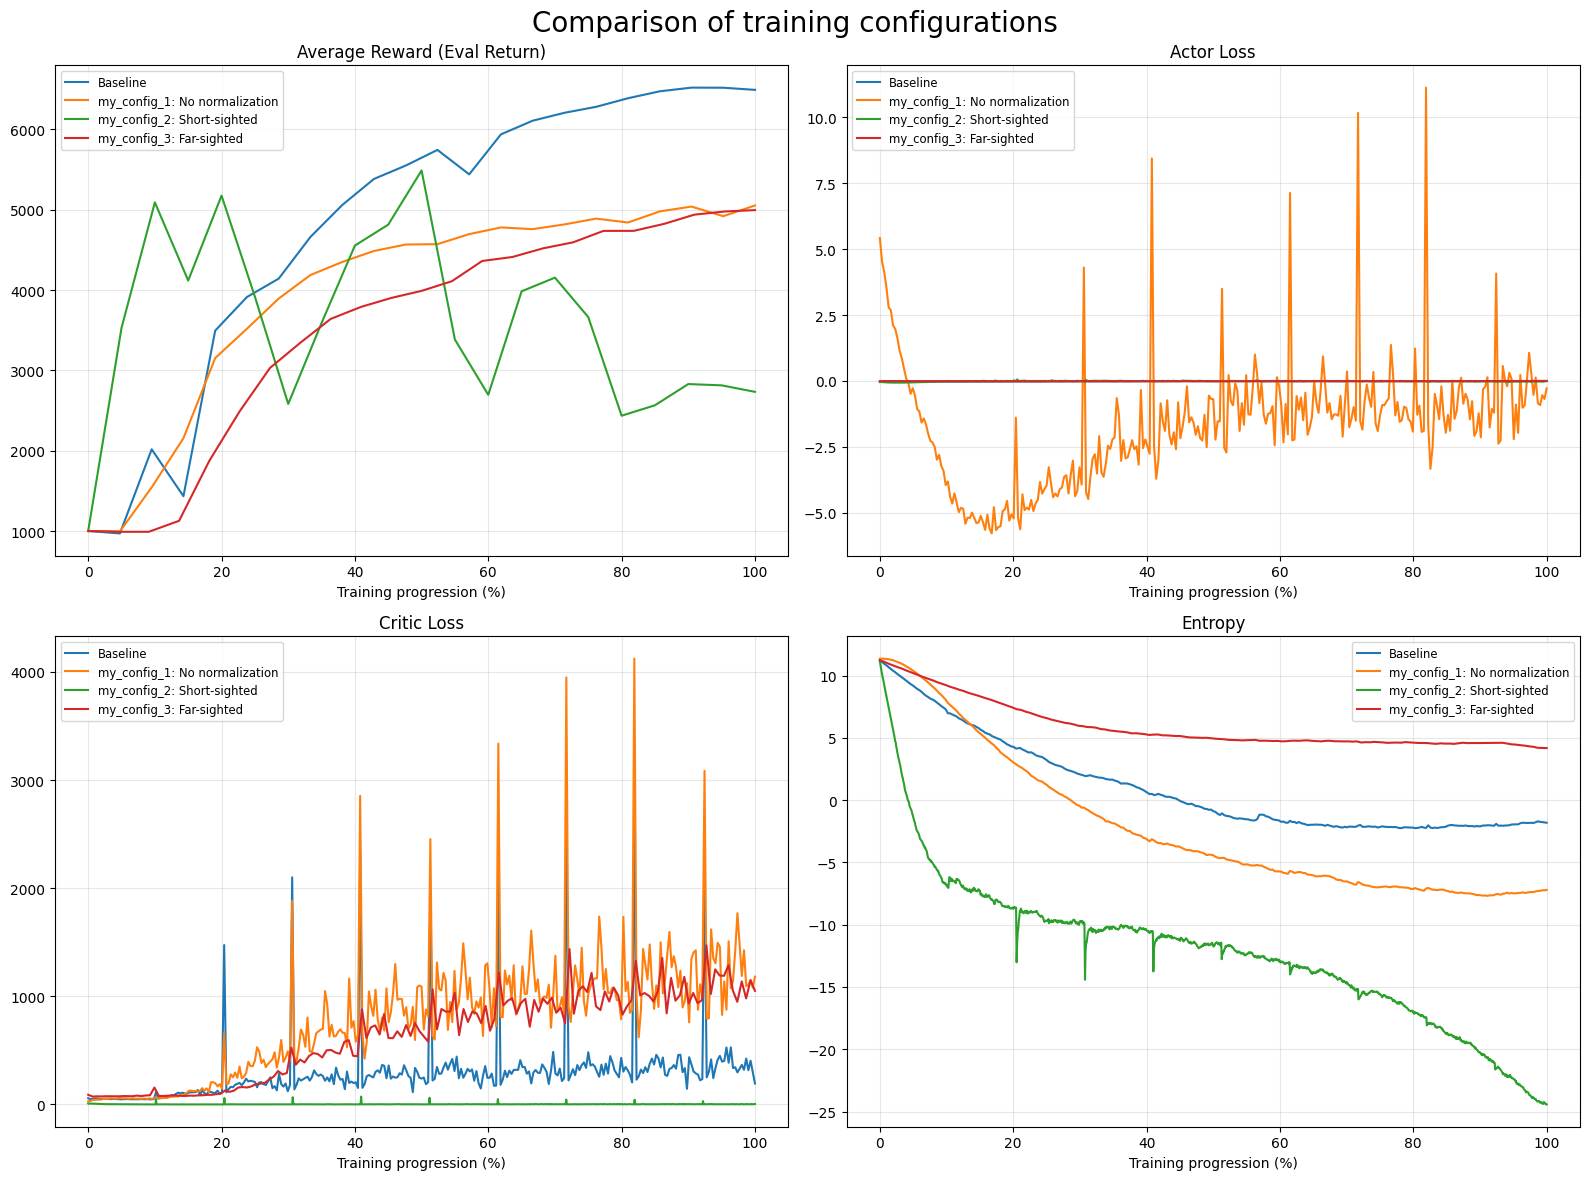

In [28]:
# vizualizations

experiments = {
    "Baseline": default_results,
    "my_config_1: No normalization": my_results_1,
    "my_config_2: Short-sighted": my_results_2,
    "my_config_3: Far-sighted": my_results_3,
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparison of training configurations', fontsize=20)

# 4 chosen metrics to plot
metrics = [
    (lambda x: x['eval_returns'], 'Average Reward (Eval Return)', axes[0, 0]),
    (lambda x: x['metrics']['actor_loss'], 'Actor Loss', axes[0, 1]),
    (lambda x: x['metrics']['value_loss'], 'Critic Loss', axes[1, 0]),
    (lambda x: x['metrics']['entropy'], 'Entropy', axes[1, 1]),
]

# creating four plots with these metrics for all configurations
for (get_data, title, ax) in metrics:
  for name, data in experiments.items():
    y = np.array(get_data(data))
    x = np.linspace(0, 100, len(y))

    ax.plot(x, y, label=name)

  ax.set_title(title)
  ax.set_xlabel('Training progression (%)')
  ax.grid(True, alpha=0.3)
  ax.legend(fontsize='small', loc='best')

plt.tight_layout()
plt.show()



The graphs reveal some interesting details about how different parameters impact the training progression. First and foremost, our default baseline achieved the best final performance. The short-sighted configuration learned extremely quickly at the start, but its lack of long-term planning eventually led to a collapse. The remaining two approaches learned quite steadily and reached reasonable scores, though still inferior to the baseline.

The actor loss plot shows that removing normalization introduces massive instability. Without it, the whole training process degrades, while in the other three approaches, the loss safely oscillates around zero.

We can also see clear differences in the critic loss. No-normalization is once again the most unstable. Among the other three, the far-sighted approach has the highest loss, followed by the baseline and then the short-sighted one. Surprisingly, these losses actually grow towards the end of training. However, this is totally logical: as our ant gets better, it starts hitting completely new reward levels. As a result, the gap between the predicted and actual score grows. Also, estimating rewards for a short rollout (like 8) is naturally much easier than for a longer one (like 64), which explains why the short-sighted loss stays the lowest.

The entropy plot highlights that the far-sighted configuration maintains high variability throughout training, constantly wanting to explore new actions. On the other hand, the short-sighted model quickly finds an optimal short-term strategy, sticks to it and drops its entropy.

Putting this all together, a common pattern emerges. Our default setting is a great balance between the short-sighted and far-sighted approaches: it neither collapses into a greedy strategy nor becomes overly obsessed with the future. We also clearly saw that skipping normalization introduces tons of instability, which directly holds the model back from achieving a better final performance.

Lastly, we initially tested an even longer `rollout_length` for the far-sighted configuration, but it led to too few updates and performed poorly, so we moved to 64. Possibly, if we trained it for more epochs, that more far-sighted approach would have played out better.